<a href="https://colab.research.google.com/github/bhavanakodali5/ObjectDectection-IIITH/blob/main/task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ultralytics yt-dlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 30.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 41.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21

In [ ]:
import os

video_url = "https://www.youtube.com/watch?v=BGNMDGM0XQk&pp=ygUWZG9nIGZ1bm55IHZpZGVvcyAyIG1pbg%3D%3D"
output_file = "input_video.mp4"

# Correct way to format a string inside os.system()
os.system(f'yt-dlp -f best -o "{output_file}" "{video_url}"')

print(f"✅ Video downloaded successfully! Saved as: {output_file}")

✅ Video downloaded successfully! Saved as: input_video.mp4


In [ ]:
import os

ffmpeg_command = 'ffmpeg -i input_video.mp4 -vf "fps=1" extracted_frames/frame_%04d.jpg'
os.system(ffmpeg_command)

print("✅ Frames extracted successfully!")

✅ Frames extracted successfully!


In [ ]:
import os
import glob
import cv2
from ultralytics import YOLO

# Load YOLOv8 segmentation model
model = YOLO("yolov8n-seg.pt")  # Ensure model file exists

# Define folder paths
frame_folder = "extracted_frames"  # Frames extracted from video
segmented_frame_folder = "segmented_frames"  # Output folder for segmented images
os.makedirs(segmented_frame_folder, exist_ok=True)

# Find all extracted frames
frame_paths = glob.glob(os.path.join(frame_folder, "*.jpg"))

if not frame_paths:
    print("⚠️ No frames found in:", frame_folder)
else:
    for frame_path in frame_paths:
        print(f"Processing: {frame_path}")
        results = model(frame_path)  # Apply segmentation

        if results and len(results) > 0:
            segmented_frame = results[0].plot()  # Get segmented output

            if segmented_frame is not None:
                output_path = os.path.join(segmented_frame_folder, os.path.basename(frame_path))
                cv2.imwrite(output_path, segmented_frame)  # Save segmented frame
            else:
                print(f"⚠️ Segmentation failed for {frame_path}")

    print("✅ Segmentation completed! Check:", segmented_frame_folder)

Processing: extracted_frames/frame_0030.jpg

image 1/1 /content/extracted_frames/frame_0030.jpg: 384x640 3 persons, 417.0ms
Speed: 10.3ms preprocess, 417.0ms inference, 51.6ms postprocess per image at shape (1, 3, 384, 640)
Processing: extracted_frames/frame_0051.jpg

image 1/1 /content/extracted_frames/frame_0051.jpg: 384x640 1 person, 1 remote, 177.7ms
Speed: 1.8ms preprocess, 177.7ms inference, 13.7ms postprocess per image at shape (1, 3, 384, 640)
Processing: extracted_frames/frame_0018.jpg

image 1/1 /content/extracted_frames/frame_0018.jpg: 384x640 1 dog, 188.4ms
Speed: 3.2ms preprocess, 188.4ms inference, 4.3ms postprocess per image at shape (1, 3, 384, 640)
Processing: extracted_frames/frame_0021.jpg

image 1/1 /content/extracted_frames/frame_0021.jpg: 384x640 3 persons, 172.5ms
Speed: 1.9ms preprocess, 172.5ms inference, 12.2ms postprocess per image at shape (1, 3, 384, 640)
Processing: extracted_frames/frame_0067.jpg

image 1/1 /content/extracted_frames/frame_0067.jpg: 384x64

In [ ]:
import os
os.makedirs("extracted_frames", exist_ok=True)

In [ ]:
import os

ffmpeg_command = 'ffmpeg -i input_video.mp4 -vf "fps=1" extracted_frames/frame_%04d.jpg'
os.system(ffmpeg_command)

print("✅ Frames extracted successfully!")

✅ Frames extracted successfully!


In [ ]:
import os

ffmpeg_command = 'ffmpeg -framerate 30 -i segmented_frames/frame_%04d.jpg -c:v libx264 -pix_fmt yuv420p segmented_video.mp4'
os.system(ffmpeg_command)

print("✅ Video created successfully!")

✅ Video created successfully!


In [ ]:
from google.colab import files

files.download("segmented_video.mp4")

print("✅ Video download initiated!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Video download initiated!


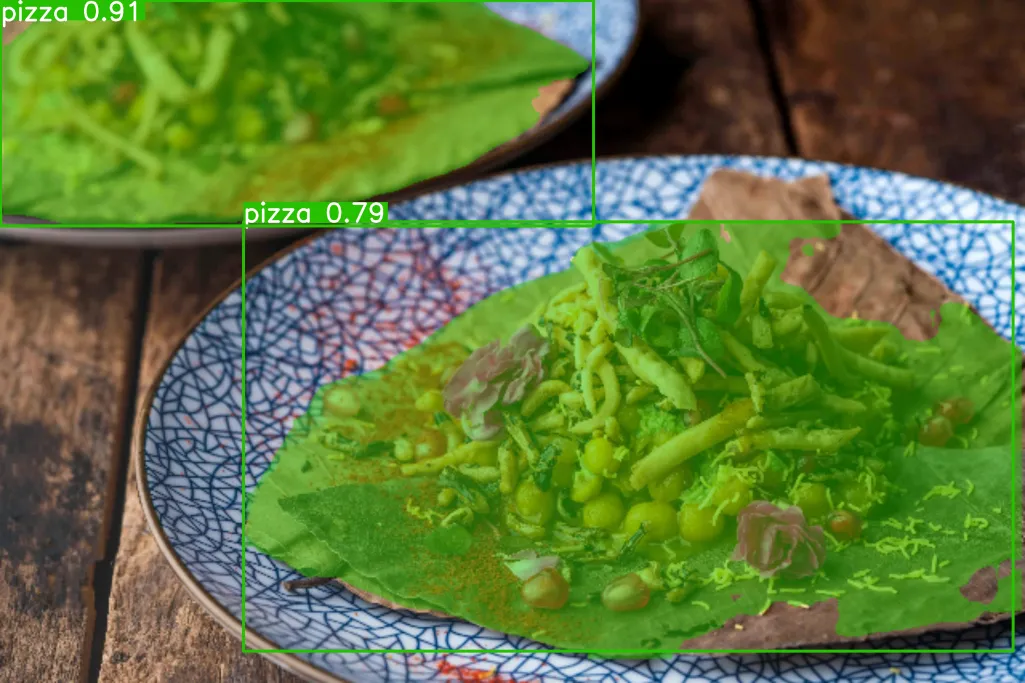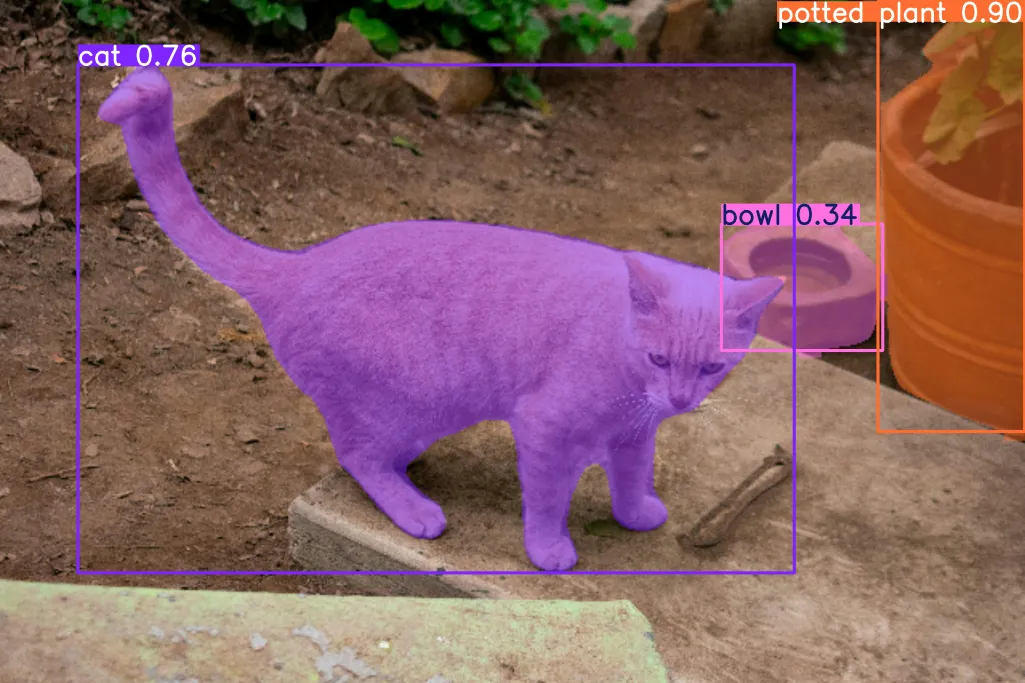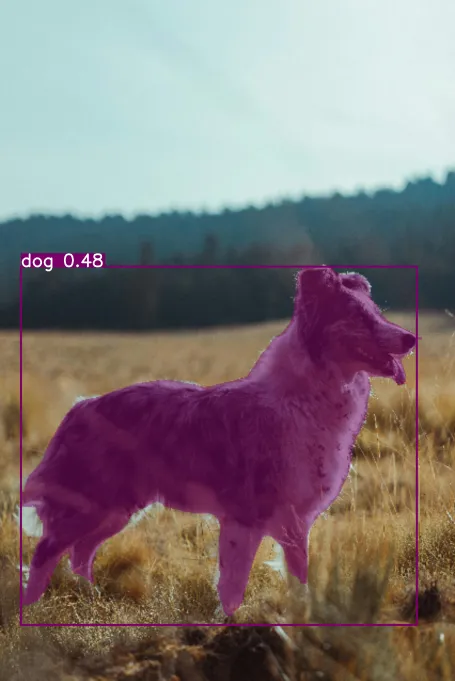